In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkplot.py

import thinkdsp
import thinkplot

--2026-05-19 20:52:38--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-19 20:52:39--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.002s  

2026-05-19 20:52:39 (23.7 MB/s) - ‘thinkdsp.py’ saved [48554/48554]

--2026-05-19 20:52:39--  https://github.com/AllenDo

# 6.2

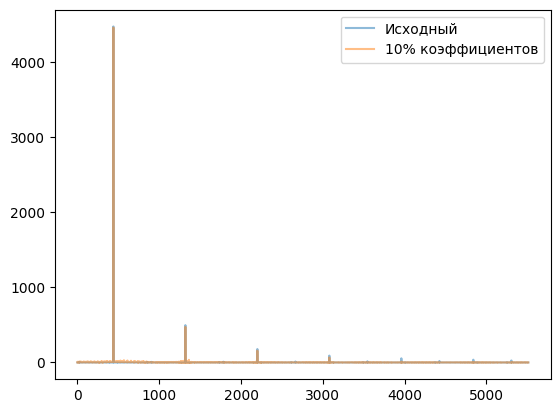

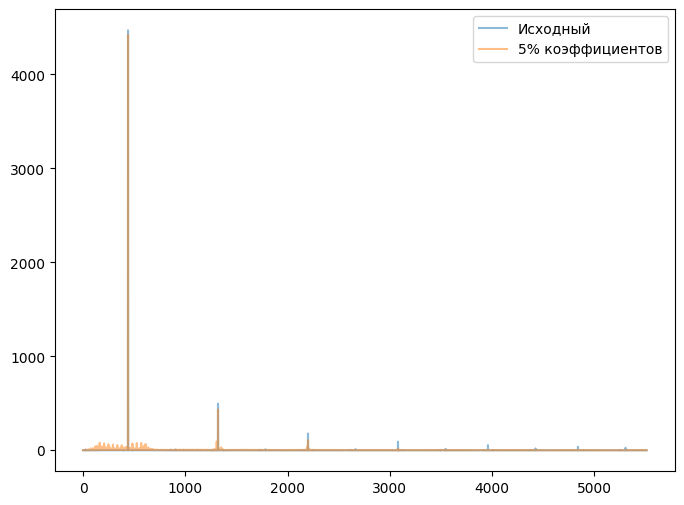

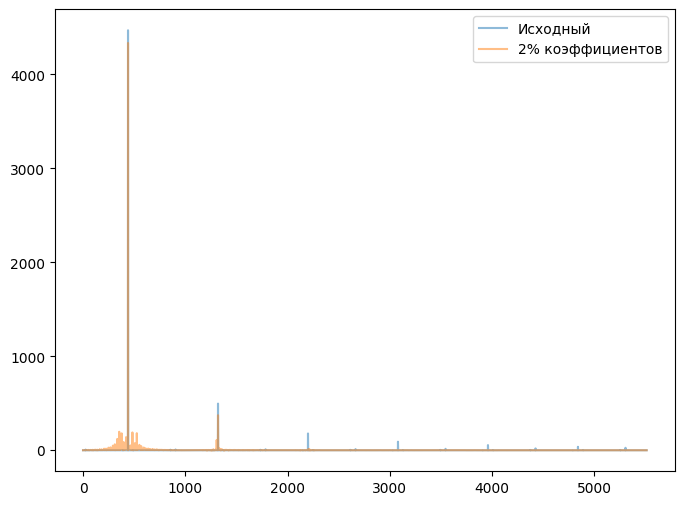

<Figure size 800x600 with 0 Axes>

In [3]:
import numpy as np
import scipy

def dct_compress(wave, fraction=0.1, seg_length=512):
    """
    Сжатие сигнала с помощью ДКП.

    wave: исходный сигнал (thinkdsp.Wave)
    fraction: доля сохраняемых коэффициентов (0..1)
    seg_length: длина сегмента (степень 2)

    Возвращает сжатый сигнал (thinkdsp.Wave)
    """
    framerate = wave.framerate
    ys = wave.ys
    N = len(ys)
    compressed = np.zeros(N)

    # Разбиваем на сегменты
    step = seg_length // 2   # перекрытие 50%
    for start in range(0, N - seg_length, step):
        segment = ys[start:start+seg_length]
        # Прямое ДКП-II
        dct = scipy.fftpack.dct(segment, type=2, norm='ortho')
        # Определяем порог: оставляем fraction самых больших по модулю
        k = int(seg_length * fraction)
        if k > 0:
            # Индексы k наибольших по модулю
            idx = np.argsort(np.abs(dct))[-k:]
            mask = np.zeros_like(dct)
            mask[idx] = 1
            dct *= mask
        # Обратное ДКТ
        segment_recon = scipy.fftpack.idct(dct, type=2, norm='ortho')
        # Накладываем с перекрытием (усреднение)
        if start == 0:
            compressed[start:start+seg_length] = segment_recon
        else:
            # Перекрывающаяся область усредняется
            overlap = seg_length // 2
            compressed[start:start+overlap] = (compressed[start:start+overlap] + segment_recon[:overlap]) / 2
            compressed[start+overlap:start+seg_length] = segment_recon[overlap:]

    return thinkdsp.Wave(compressed, framerate=framerate)

from scipy import fftpack as scipy_fftpack
scipy.fftpack = scipy_fftpack

signal = thinkdsp.TriangleSignal(freq=440)
wave = signal.make_wave(duration=1, framerate=11025)

for frac in [0.1, 0.05, 0.02]:
    compressed = dct_compress(wave, fraction=frac, seg_length=512)
    # Сравним спектры
    orig_spec = wave.make_spectrum()
    comp_spec = compressed.make_spectrum()
    orig_spec.plot(alpha=0.5, label='Исходный')
    comp_spec.plot(alpha=0.5, label=f'{int(frac*100)}% коэффициентов')
    thinkplot.show()

ри сохранении 10% коэффициентов искажения почти незаметны на слух. При 5% появляется небольшой шум ("звон"), а при 2% – заметные артефакты.


# 6.3

In [6]:
if not os.path.exists('28042__bcjordan__voicedownbew.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/28042__bcjordan__voicedownbew.wav

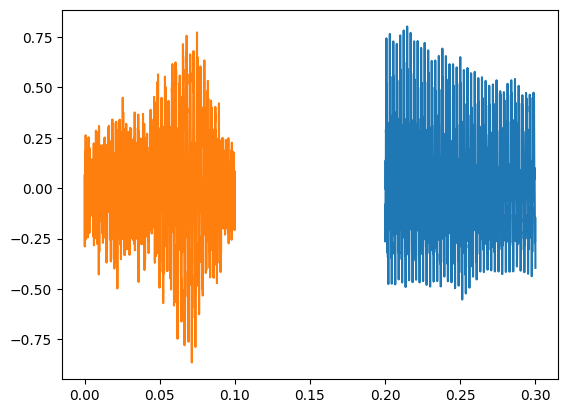

Корреляция между исходным и сигналом со случайными фазами: -0.272


<Figure size 800x600 with 0 Axes>

In [8]:
import numpy as np

def randomize_phases(spectrum):
    """Изменяет фазы всех частотных компонент случайным образом."""
    hs = spectrum.hs.copy()
    amps = np.abs(hs)
    phases = np.random.uniform(0, 2*np.pi, len(hs))
    spectrum.hs = amps * np.exp(1j * phases)
    return spectrum

wave = thinkdsp.read_wave('28042__bcjordan__voicedownbew.wav')
segment = wave.segment(start=0.2, duration=0.1)

spectrum = segment.make_spectrum()
spectrum2 = spectrum.copy()
randomize_phases(spectrum2)

wave1 = segment
wave2 = spectrum2.make_wave()

thinkplot.preplot(2)
wave1.plot()
wave2.plot()
thinkplot.show()

# Вычисление и вывод корреляции между сигналами
corr = wave1.corr(wave2)
print(f"Корреляция между исходным и сигналом со случайными фазами: {corr:.3f}")

In [11]:
wave1.make_audio()

In [12]:
wave2.make_audio()

Cигналы звучат по-разному. Корреляция между ними мала. Это демонстрирует, что фаза играет важную роль в восприятии звука, особенно для сложных сигналов. Однако для простых периодических сигналов (например, синусоиды) изменение фазы не меняет звучание.